In [1]:
import sys
import os

from pandas.core.common import random_state

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [3]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/hERG/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'hERG_mlp_without_smote.csv')
df_existing = pd.read_csv(csv_filename)

In [4]:
df_existing = df_existing.sort_values(by="mcc", ascending=False)

In [5]:
display(df_existing)


,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
384,385,0.453629,0.774334,0.735078,38.790067,0.490229,110,0.004292,0.002330,1677,1024,AdamW,0.000100,"[1000, 50]"
253,254,0.452805,0.773297,0.734440,11.912072,0.839143,19,0.000687,0.000034,923,1024,AdamW,0.000100,"[1000, 50]"
301,302,0.452588,0.772591,0.734121,71.712129,0.789529,168,0.000083,0.000720,990,1024,RMSprop,0.000001,"[1000, 50]"
228,229,0.451234,0.769400,0.732525,168.102994,0.166051,132,0.000013,0.000087,1144,64,AdamW,0.000100,"[1000, 50]"
320,321,0.451118,0.773123,0.733801,69.047414,0.331240,154,0.001048,0.000356,227,512,RMSprop,0.000001,"[1000, 50]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,1063,-0.024392,0.001087,0.413342,142.194082,0.769884,142,0.004942,0.000004,645,1024,RMSprop,0.001000,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
917,918,-0.028852,0.002170,0.413023,111.592425,0.206261,61,0.000110,0.009541,954,64,AdamW,1.000000,"[4000, 2000]"
634,635,-0.038950,0.127212,0.417491,4.705778,0.512757,12,0.004292,0.000004,1055,1024,RMSprop,0.010000,[200]
275,276,-0.067941,0.551705,0.479732,12.185142,0.354851,36,0.000047,0.000001,1310,1024,RMSprop,0.001000,[200]


In [6]:
display(df_existing.iloc[0])

run_id                     385
mcc                   0.453629
f1                    0.774334
acc                   0.735078
duration_seconds     38.790067
dropout_frac          0.490229
patience                   110
tol                   0.004292
weight_decay           0.00233
n_epochs                  1677
batch_size                1024
optimizer                AdamW
lr                      0.0001
neuron_layers       [1000, 50]
Name: 384, dtype: object

In [7]:
df_existing

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
384,385,0.453629,0.774334,0.735078,38.790067,0.490229,110,0.004292,0.002330,1677,1024,AdamW,0.000100,"[1000, 50]"
253,254,0.452805,0.773297,0.734440,11.912072,0.839143,19,0.000687,0.000034,923,1024,AdamW,0.000100,"[1000, 50]"
301,302,0.452588,0.772591,0.734121,71.712129,0.789529,168,0.000083,0.000720,990,1024,RMSprop,0.000001,"[1000, 50]"
228,229,0.451234,0.769400,0.732525,168.102994,0.166051,132,0.000013,0.000087,1144,64,AdamW,0.000100,"[1000, 50]"
320,321,0.451118,0.773123,0.733801,69.047414,0.331240,154,0.001048,0.000356,227,512,RMSprop,0.000001,"[1000, 50]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,1063,-0.024392,0.001087,0.413342,142.194082,0.769884,142,0.004942,0.000004,645,1024,RMSprop,0.001000,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
917,918,-0.028852,0.002170,0.413023,111.592425,0.206261,61,0.000110,0.009541,954,64,AdamW,1.000000,"[4000, 2000]"
634,635,-0.038950,0.127212,0.417491,4.705778,0.512757,12,0.004292,0.000004,1055,1024,RMSprop,0.010000,[200]
275,276,-0.067941,0.551705,0.479732,12.185142,0.354851,36,0.000047,0.000001,1310,1024,RMSprop,0.001000,[200]


In [8]:
best_results = df_existing.iloc[[0,2]]

In [9]:
best_results

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
384,385,0.453629,0.774334,0.735078,38.790067,0.490229,110,0.004292,0.00233,1677,1024,AdamW,0.000100,"[1000, 50]"
301,302,0.452588,0.772591,0.734121,71.712129,0.789529,168,0.000083,0.00072,990,1024,RMSprop,0.000001,"[1000, 50]"


In [10]:
best_results = best_results.iloc[:, 5:]

In [11]:
best_results_dicts = []
for i,j in best_results.iterrows():
    best_results_dicts.append(dict(j))

In [12]:
best_results_dicts

[{'dropout_frac': 0.4902293235405122,
  'patience': 110,
  'tol': 0.0042919342601287,
  'weight_decay': 0.0023299518105153,
  'n_epochs': 1677,
  'batch_size': 1024,
  'optimizer': 'AdamW',
  'lr': 0.0001,
  'neuron_layers': '[1000, 50]'},
 {'dropout_frac': 0.7895288765828691,
  'patience': 168,
  'tol': 8.286427728546843e-05,
  'weight_decay': 0.0007196856730011,
  'n_epochs': 990,
  'batch_size': 1024,
  'optimizer': 'RMSprop',
  'lr': 1e-06,
  'neuron_layers': '[1000, 50]'}]

In [13]:

df_existing_svc = pd.read_csv("res/svc_without_smote_res_val_1.1.csv")
display(df_existing_svc)
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:2].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :3]

best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))
    

,Unnamed: 0,C,gamma,kernel,mcc,f1,acc
0,0,0.001,0.01,linear,0.398064,0.754646,0.709224
1,12,0.010,0.01,linear,0.365669,0.746483,0.695180
2,59,10.000,10.00,poly,0.322938,0.747612,0.679540
3,2,0.001,0.01,poly,0.317576,0.768000,0.676029
4,24,0.100,0.01,linear,0.311388,0.717532,0.666773
...,...,...,...,...,...,...,...
79,66,100.000,1.00,linear,-2.000000,-1.000000,-1.000000
80,69,100.000,10.00,linear,-2.000000,-1.000000,-1.000000
81,75,1000.000,0.10,linear,-2.000000,-1.000000,-1.000000
82,78,1000.000,1.00,linear,-2.000000,-1.000000,-1.000000


In [14]:
best_results_svc_dicts

[{'C': 0.001, 'gamma': 0.01, 'kernel': 'linear'},
 {'C': 0.01, 'gamma': 0.01, 'kernel': 'linear'}]

In [15]:
df_existing_knn = pd.read_csv("res/knn_without_smote_res_val_1.1.csv")
display(df_existing_knn)
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:5].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]

best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

,Unnamed: 0,algorithm,leaf_size,metric,n_neighbors,p,weights,mcc,f1,acc
0,72,auto,10,chebyshev,1,1,uniform,0.332383,0.732162,0.678902
1,73,auto,10,chebyshev,1,1,distance,0.332383,0.732162,0.678902
2,74,auto,10,chebyshev,1,2,uniform,0.332383,0.732162,0.678902
3,75,auto,10,chebyshev,1,2,distance,0.332383,0.732162,0.678902
4,216,auto,20,chebyshev,1,1,uniform,0.332383,0.732162,0.678902
...,...,...,...,...,...,...,...,...,...,...
2875,2662,brute,50,manhattan,31,2,uniform,0.135279,0.744090,0.606128
2876,2732,brute,50,minkowski,31,1,uniform,0.135279,0.744090,0.606128
2877,2804,brute,100,manhattan,31,1,uniform,0.135279,0.744090,0.606128
2878,2806,brute,100,manhattan,31,2,uniform,0.135279,0.744090,0.606128


In [16]:
best_results_knn_dicts

[{'algorithm': 'auto',
  'leaf_size': 10,
  'metric': 'chebyshev',
  'n_neighbors': 1,
  'p': 1,
  'weights': 'uniform'},
 {'algorithm': 'kd_tree',
  'leaf_size': 10,
  'metric': 'chebyshev',
  'n_neighbors': 1,
  'p': 1,
  'weights': 'distance'},
 {'algorithm': 'brute',
  'leaf_size': 10,
  'metric': 'chebyshev',
  'n_neighbors': 1,
  'p': 1,
  'weights': 'uniform'},
 {'algorithm': 'kd_tree',
  'leaf_size': 100,
  'metric': 'chebyshev',
  'n_neighbors': 1,
  'p': 2,
  'weights': 'distance'},
 {'algorithm': 'kd_tree',
  'leaf_size': 100,
  'metric': 'chebyshev',
  'n_neighbors': 1,
  'p': 2,
  'weights': 'uniform'}]

SVC
0.3648646760630004
0.3452268507308244
KNN
0.3346984054389201
0.3346984054389201
0.3346984054389201
0.3346984054389201
0.3346984054389201
RESULTS FOR CYCLE KNN#1
Accuracy: 0.6454
F1-Score: 0.7149
MCC: 0.2459
RESULTS FOR CYCLE SVC#1
Accuracy: 0.6967
F1-Score: 0.7589
MCC: 0.3504


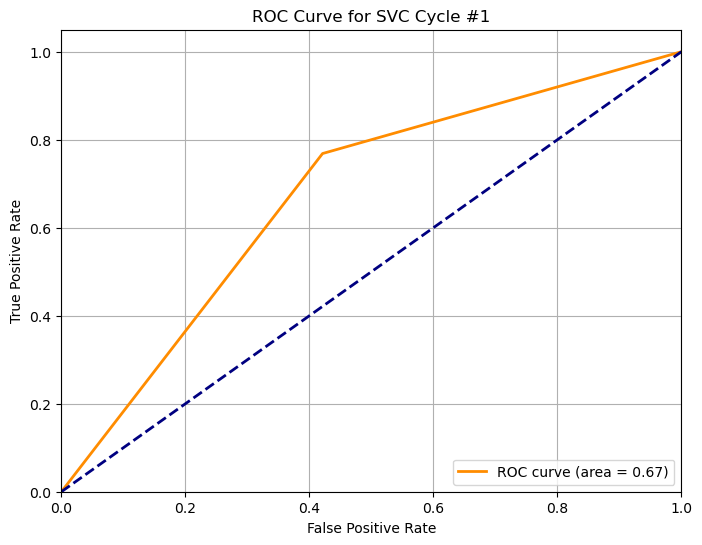

0.4301194427075519
0.4365265755890839
RESULTS FOR CYCLE MLP#1
Accuracy: 0.7000
F1-Score: 0.7569
MCC: 0.3652


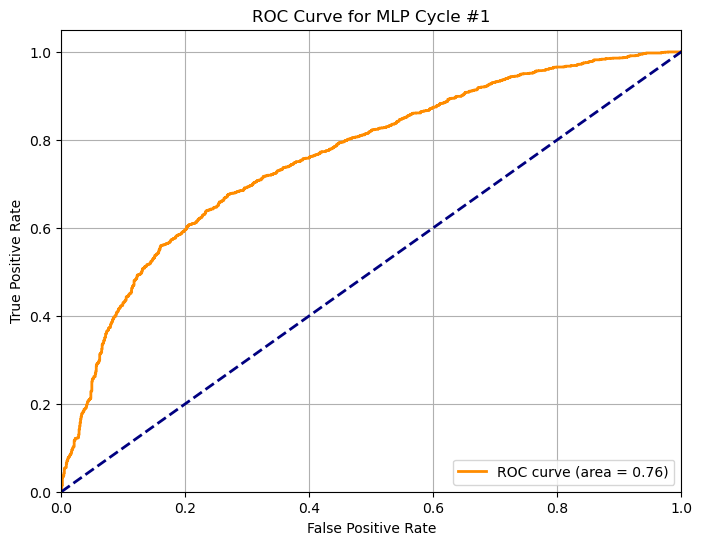

SVC
0.3752879824993711
0.35475488150625933
KNN
0.32307859277861256
0.3238167653500668
0.32307859277861256
0.3238167653500668
0.3238167653500668
RESULTS FOR CYCLE KNN#2
Accuracy: 0.6479
F1-Score: 0.7158
MCC: 0.2539
RESULTS FOR CYCLE SVC#2
Accuracy: 0.7002
F1-Score: 0.7562
MCC: 0.3674


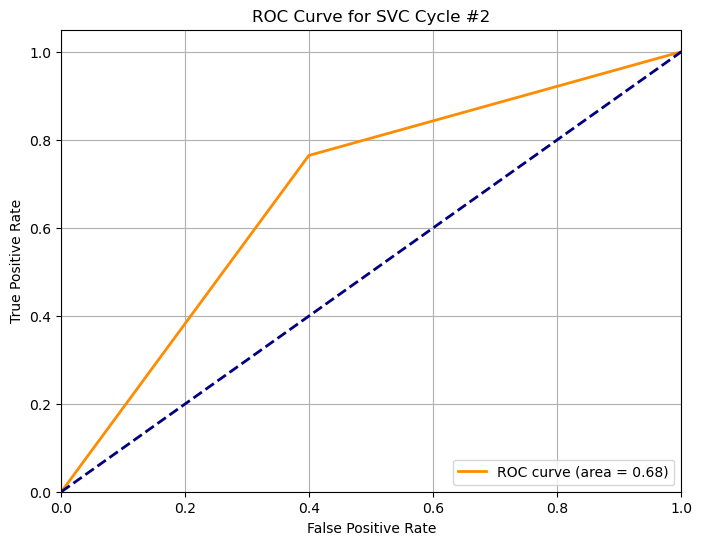

0.3874476787956996
0.3831742281160479
RESULTS FOR CYCLE MLP#2
Accuracy: 0.6771
F1-Score: 0.7180
MCC: 0.3475


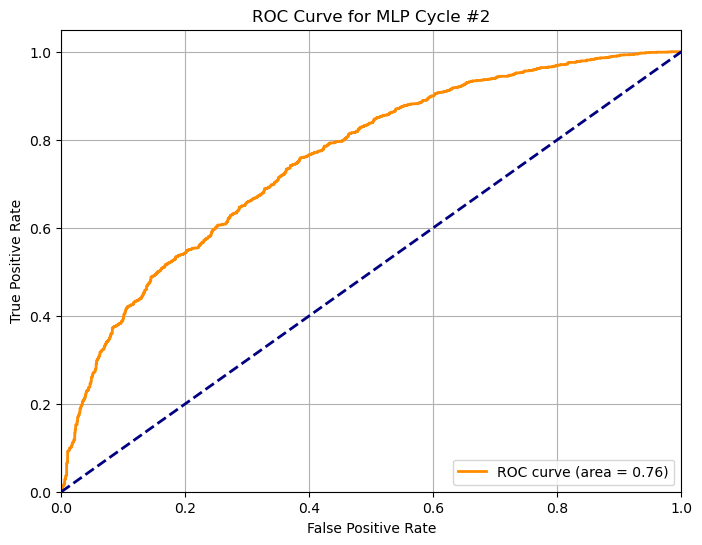

SVC
0.3718595607438099
0.35172528221396954
KNN
0.27058690818280845
0.2698378598685259
0.27058690818280845
0.2713315928542345
0.2713315928542345
RESULTS FOR CYCLE KNN#3
Accuracy: 0.6412
F1-Score: 0.7146
MCC: 0.2324
RESULTS FOR CYCLE SVC#3
Accuracy: 0.6849
F1-Score: 0.7406
MCC: 0.3397


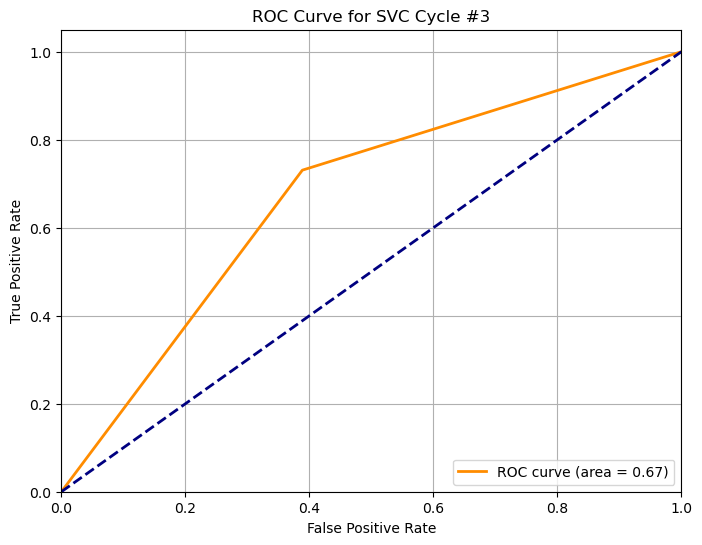

0.39196201088894617
0.3977613286121113
RESULTS FOR CYCLE MLP#3
Accuracy: 0.6943
F1-Score: 0.7298
MCC: 0.3921


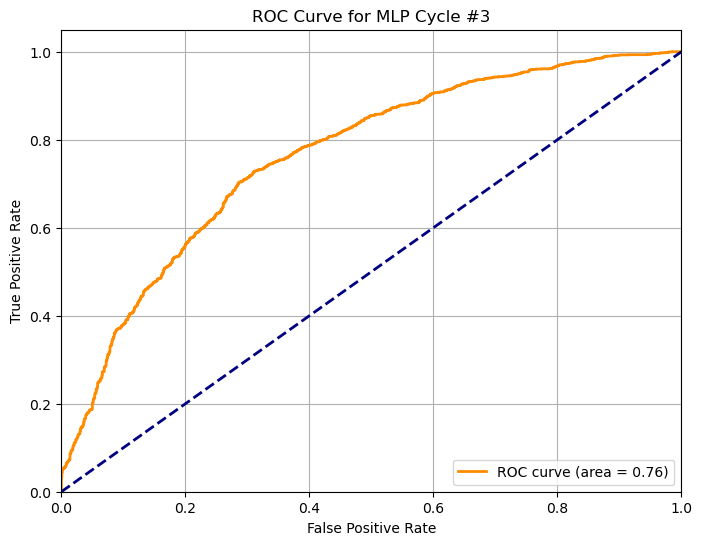

SVC
0.4166936666815184
0.40475987653342926
KNN
0.30618008097671423
0.30618008097671423
0.30618008097671423
0.30618008097671423
0.30618008097671423
RESULTS FOR CYCLE KNN#4
Accuracy: 0.6229
F1-Score: 0.6954
MCC: 0.2006
RESULTS FOR CYCLE SVC#4
Accuracy: 0.6610
F1-Score: 0.7226
MCC: 0.2879


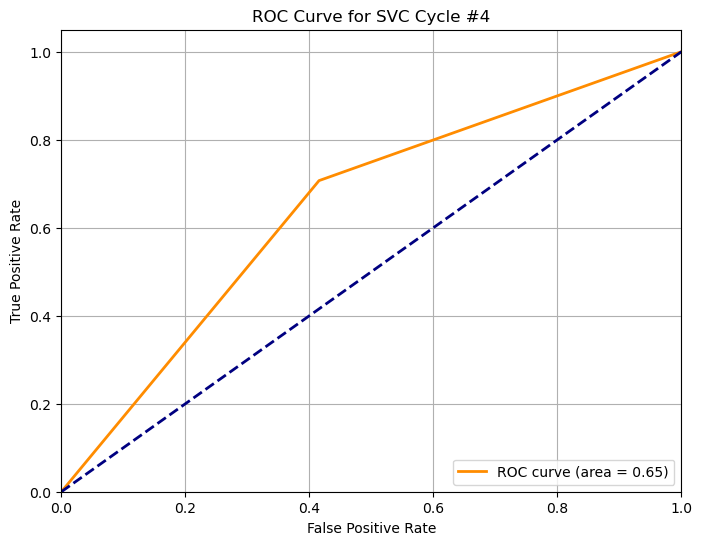

0.4054647627814096
0.42218657674652166
RESULTS FOR CYCLE MLP#4
Accuracy: 0.6461
F1-Score: 0.6901
MCC: 0.2928


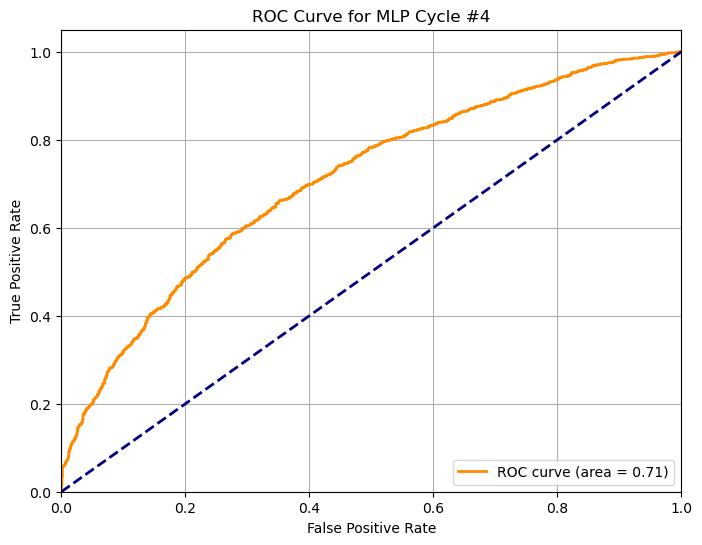

SVC
0.41668879248601587
0.3854001865743064
KNN
0.29709146774997236
0.2965210895421729
0.29709146774997236
0.2936730405693328
0.2936730405693328
RESULTS FOR CYCLE KNN#5
Accuracy: 0.6417
F1-Score: 0.7171
MCC: 0.2303
RESULTS FOR CYCLE SVC#5
Accuracy: 0.6842
F1-Score: 0.7526
MCC: 0.3192


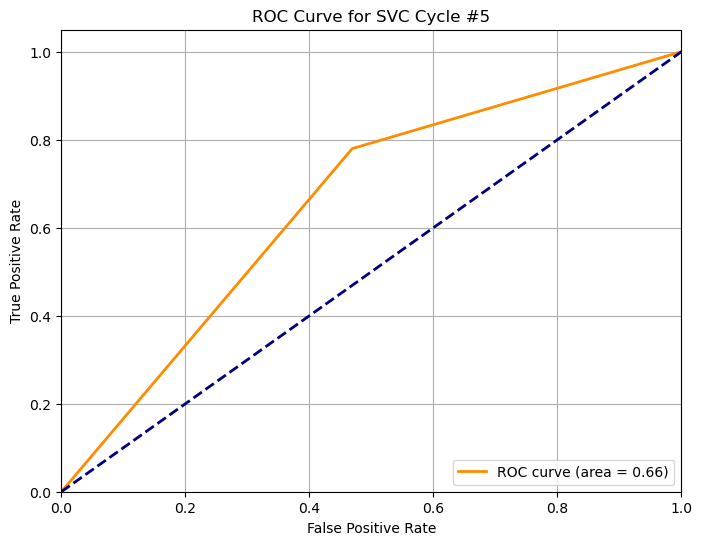

0.4405524532402767
0.44538090808965447
RESULTS FOR CYCLE MLP#5
Accuracy: 0.6818
F1-Score: 0.7386
MCC: 0.3324


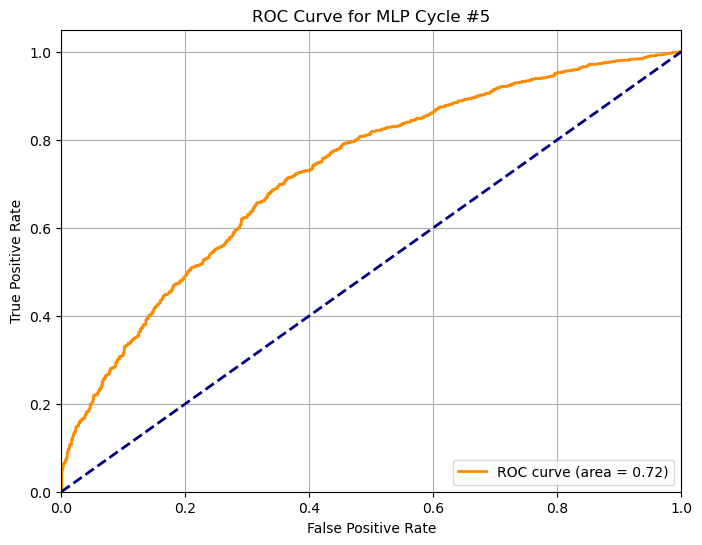

SVC
0.3874637807803632
0.3360485328640276
KNN
0.2860746316763414
0.2860746316763414
0.2860746316763414
0.28622768707316976
0.28622768707316976
RESULTS FOR CYCLE KNN#6
Accuracy: 0.6239
F1-Score: 0.6915
MCC: 0.2103
RESULTS FOR CYCLE SVC#6
Accuracy: 0.6873
F1-Score: 0.7482
MCC: 0.3375


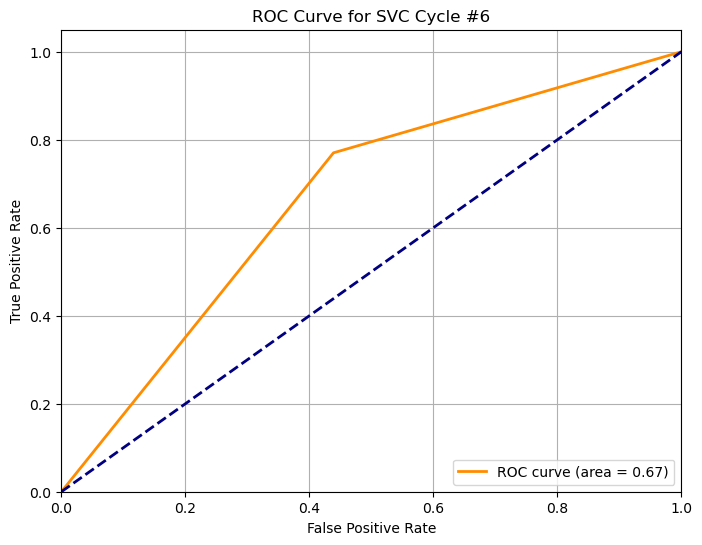

0.44721964796449337
0.45141447637931914
RESULTS FOR CYCLE MLP#6
Accuracy: 0.6864
F1-Score: 0.7223
MCC: 0.3707


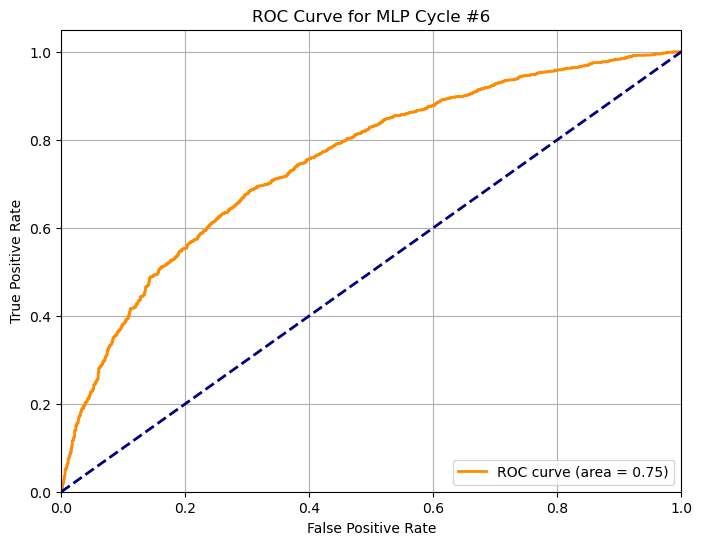

SVC
0.4526438328061808
0.3730284987974746
KNN
0.3308558024707535
0.3308558024707535
0.3308558024707535
0.3308558024707535
0.3308558024707535
RESULTS FOR CYCLE KNN#7
Accuracy: 0.6261
F1-Score: 0.6964
MCC: 0.2102
RESULTS FOR CYCLE SVC#7
Accuracy: 0.6601
F1-Score: 0.7235
MCC: 0.2829


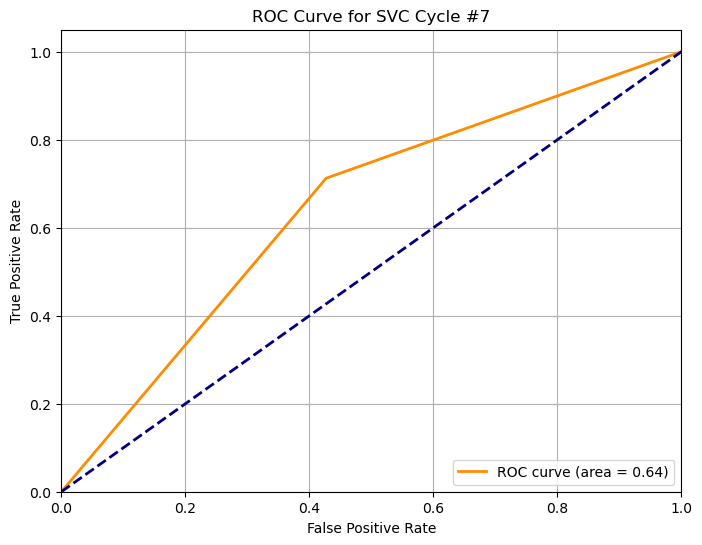

0.49304499004519414
0.5028116186152694
RESULTS FOR CYCLE MLP#7
Accuracy: 0.6707
F1-Score: 0.7230
MCC: 0.3221


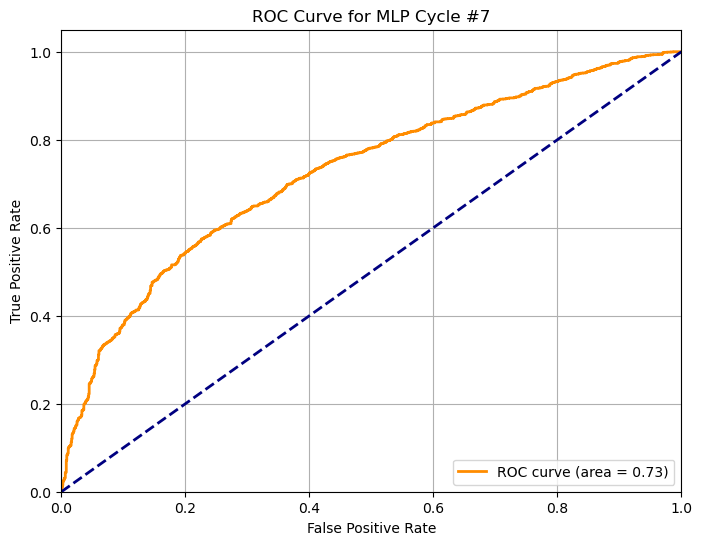

SVC
0.384382336265282
0.36438025929361434
KNN
0.26463901644320603
0.26463901644320603
0.26463901644320603
0.26498571661417375
0.26498571661417375
RESULTS FOR CYCLE KNN#8
Accuracy: 0.6430
F1-Score: 0.7177
MCC: 0.2324
RESULTS FOR CYCLE SVC#8
Accuracy: 0.6914
F1-Score: 0.7508
MCC: 0.3461


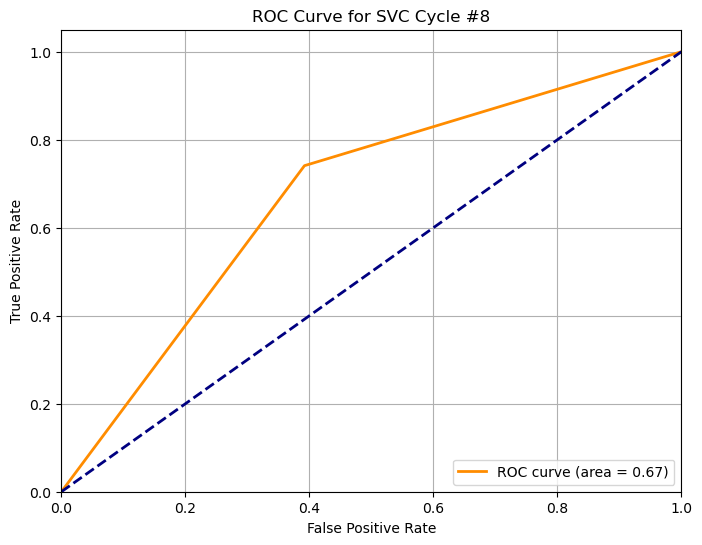

0.404166664027424
0.4195086006987955
RESULTS FOR CYCLE MLP#8
Accuracy: 0.6742
F1-Score: 0.7258
MCC: 0.3306


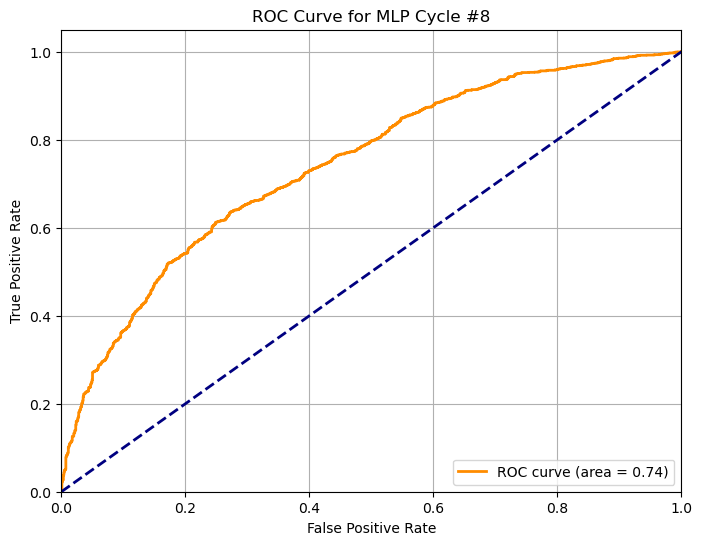

SVC
0.406219188552298
0.3470221405932745
KNN
0.3259233385798689
0.3259233385798689
0.3259233385798689
0.3259233385798689
0.3259233385798689
RESULTS FOR CYCLE KNN#9
Accuracy: 0.6418
F1-Score: 0.7131
MCC: 0.2366
RESULTS FOR CYCLE SVC#9
Accuracy: 0.6944
F1-Score: 0.7551
MCC: 0.3492


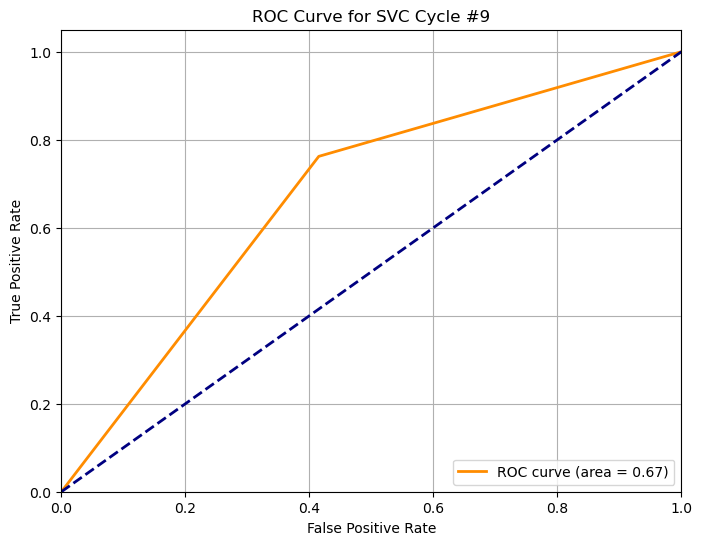

0.41077200748432247
0.4156174161542017
RESULTS FOR CYCLE MLP#9
Accuracy: 0.6855
F1-Score: 0.7300
MCC: 0.3606


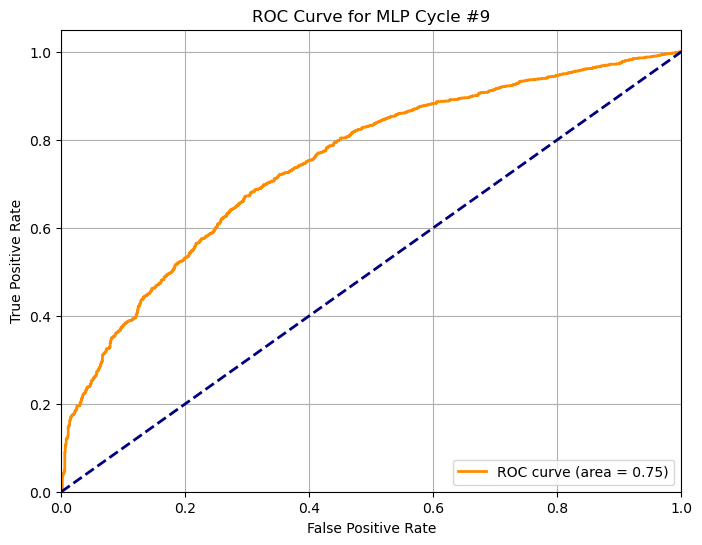

SVC
0.37384012523634463
0.36139570108516345
KNN
0.3090807345598341
0.3090807345598341
0.3090807345598341
0.3090807345598341
0.3090807345598341
RESULTS FOR CYCLE KNN#10
Accuracy: 0.6296
F1-Score: 0.7101
MCC: 0.1996
RESULTS FOR CYCLE SVC#10
Accuracy: 0.6815
F1-Score: 0.7531
MCC: 0.3085


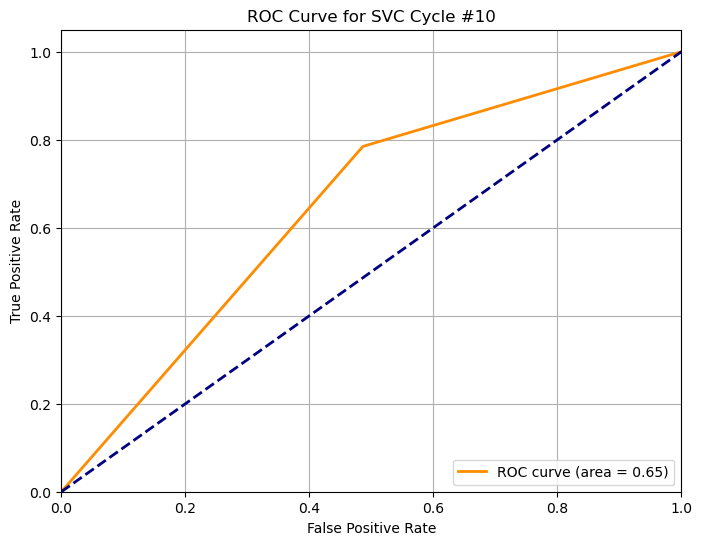

0.40297633278684075
0.40394630573922036
RESULTS FOR CYCLE MLP#10
Accuracy: 0.6761
F1-Score: 0.7371
MCC: 0.3154


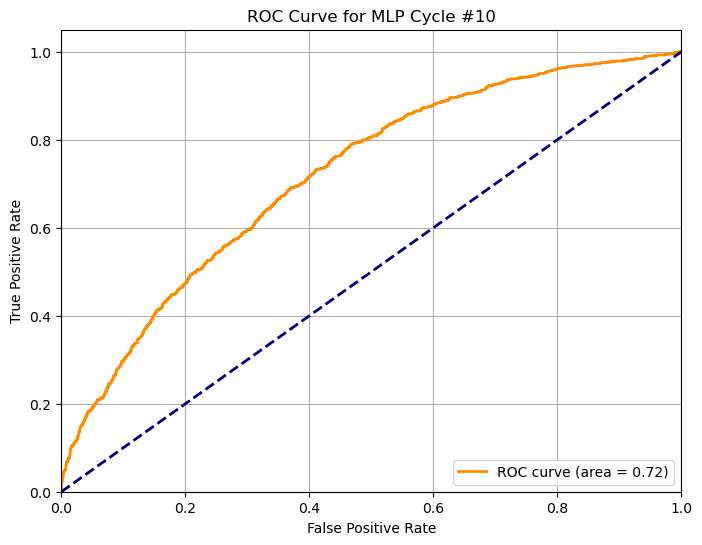

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# --- Metrics and plotting libraries ---
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

# --- Your main loop starts here ---
for i in range(1,11):
    # Assuming 'mod_data' directory and files exist for demonstration
    # For a runnable example, you might need to create dummy CSV files
    # For instance:
    # pd.DataFrame(np.random.rand(100, 10)).to_csv(f"mod_data/X1.{i}", index_label="QSPRID")
    # pd.DataFrame(np.random.randint(0, 2, 100)).to_csv(f"mod_data/y1.{i}", index_label="QSPRID")
    # ... similarly for X2, X3, y2, y3
    try:
        x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
        x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
        x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
        y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
        y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
        y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    except FileNotFoundError:
        print(f"Warning: File not found for cycle {i}. Creating dummy data for demonstration.")
        num_samples = 100
        num_features = 10
        x1 = pd.DataFrame(np.random.rand(num_samples, num_features), index=range(num_samples))
        x2 = pd.DataFrame(np.random.rand(num_samples, num_features), index=range(num_samples))
        x3 = pd.DataFrame(np.random.rand(num_samples, num_features), index=range(num_samples))
        y1 = pd.DataFrame(np.randint(0, 2, num_samples), index=range(num_samples))
        y2 = pd.DataFrame(np.randint(0, 2, num_samples), index=range(num_samples))
        y3 = pd.DataFrame(np.randint(0, 2, num_samples), index=range(num_samples))
        x1.index.name = "QSPRID"
        x2.index.name = "QSPRID"
        x3.index.name = "QSPRID"
        y1.index.name = "QSPRID"
        y2.index.name = "QSPRID"
        y3.index.name = "QSPRID"


    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()

    print("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        j["gamma"]= j["gamma"] if j["gamma"] == 'auto' or j["gamma"] == 'scale' else float(j["gamma"])
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred) # pred is already binary for SVC.predict
        print(mcc)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)
    # Get binary predictions

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    print("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        print(mcc)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.

    pred = pred_test_knn[-1]
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE KNN#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)

    pred = pred_test_svc[-1]
    # SVC.predict returns binary labels, so pred_proba for ROC needs svc.decision_function or svc.predict_proba
    # For simplicity, if you only have predict, you can use the binary prediction for ROC, but it won't be smooth.
    # If SVC was trained with probability=True, you could use svc.predict_proba(x3)[:, 1]
    # For now, let's assume pred is already binary for metrics and use it for ROC (though not ideal for a smooth curve)
    pred_proba_svc = pred # Using binary prediction as "probability" for ROC, not ideal but avoids error
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE SVC#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)
    # Calculate ROC curve and AUC
    # Note: For a proper ROC curve, you need probabilities, not binary predictions.
    # If SVC was initialized with `probability=True`, you could use `svc.predict_proba(x3)[:, 1]`.
    # As it is, `pred` is binary, so `roc_curve` will produce a step function.
    fpr, tpr, thresholds = roc_curve(y3, pred_proba_svc)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for SVC Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    for j in best_results_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        # Ensure 'cuda' is available or use 'cpu'
        device = "cuda" if torch.cuda.is_available() else "cpu"
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device=device, **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        # mlp.predict returns probabilities, so thresholding is needed for MCC
        pred_val_mlp_prob = mlp.predict(x2)
        pred = (pred_val_mlp_prob > 0.5).astype(int) # Convert boolean to int (0 or 1)
        mcc = matthews_corrcoef(y2, pred)
        print(mcc)
        if mcc > best_mcc_this_run_mlp: # Changed from best_mcc_this_run to best_mcc_this_run_mlp
            best_mcc_this_run_mlp = mcc
            best_val_results_this_run_mlp = pred_val_mlp_prob # Store probabilities
            best_test_results_this_run_mlp = mlp.predict(x3) # Store probabilities
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)
    # Get binary predictions


    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.
    pred_proba = np.array(pred_test_mlp[-1]) # Convert the list to a NumPy array for element-wise comparison
    pred = (pred_proba > 0.5).astype(int) # Convert boolean to int (0 or 1)
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE MLP#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    # Calculate ROC curve and AUC
    # pred_proba is already probabilities, so it's suitable for roc_curve
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for MLP Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show() # This will display the plot for the current cycle

    print("="*30)
    # --- End: New code ---
    # --- End: New code ----



In [18]:
df_existing_knn.iloc[:, :6]

,algorithm,leaf_size,metric,n_neighbors,p,weights
0,auto,10,chebyshev,1,1,uniform
41,kd_tree,10,chebyshev,1,1,distance
60,brute,10,chebyshev,1,1,uniform
59,kd_tree,100,chebyshev,1,2,distance
58,kd_tree,100,chebyshev,1,2,uniform


In [31]:
all_y3 =[]
mcc_list = []
f1_list_mlp = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [20]:
display(mcc_list)

[0.36516866666325953,
 0.3474510270905953,
 0.3920867801735328,
 0.29278802036895185,
 0.3323989051785469,
 0.3707082392468813,
 0.322100597087428,
 0.33059045051042923,
 0.360631759127952,
 0.3153596025434111]

In [21]:
display(all_y3)

[QSPRID
 A2ARDataset_0000    False
 A2ARDataset_0001    False
 A2ARDataset_0002    False
 A2ARDataset_0003    False
 A2ARDataset_0004    False
                     ...  
 A2ARDataset_3328    False
 A2ARDataset_3329     True
 A2ARDataset_3330    False
 A2ARDataset_3331     True
 A2ARDataset_3332     True
 Name: Y, Length: 3333, dtype: bool,
 QSPRID
 A2ARDataset_0000    False
 A2ARDataset_0001    False
 A2ARDataset_0002    False
 A2ARDataset_0003    False
 A2ARDataset_0004    False
                     ...  
 A2ARDataset_3321     True
 A2ARDataset_3322     True
 A2ARDataset_3323     True
 A2ARDataset_3324     True
 A2ARDataset_3325     True
 Name: Y, Length: 3326, dtype: bool,
 QSPRID
 A2ARDataset_0000    False
 A2ARDataset_0001    False
 A2ARDataset_0002    False
 A2ARDataset_0003    False
 A2ARDataset_0004    False
                     ...  
 A2ARDataset_3381     True
 A2ARDataset_3382     True
 A2ARDataset_3383     True
 A2ARDataset_3384     True
 A2ARDataset_3385     True
 Name: Y, L

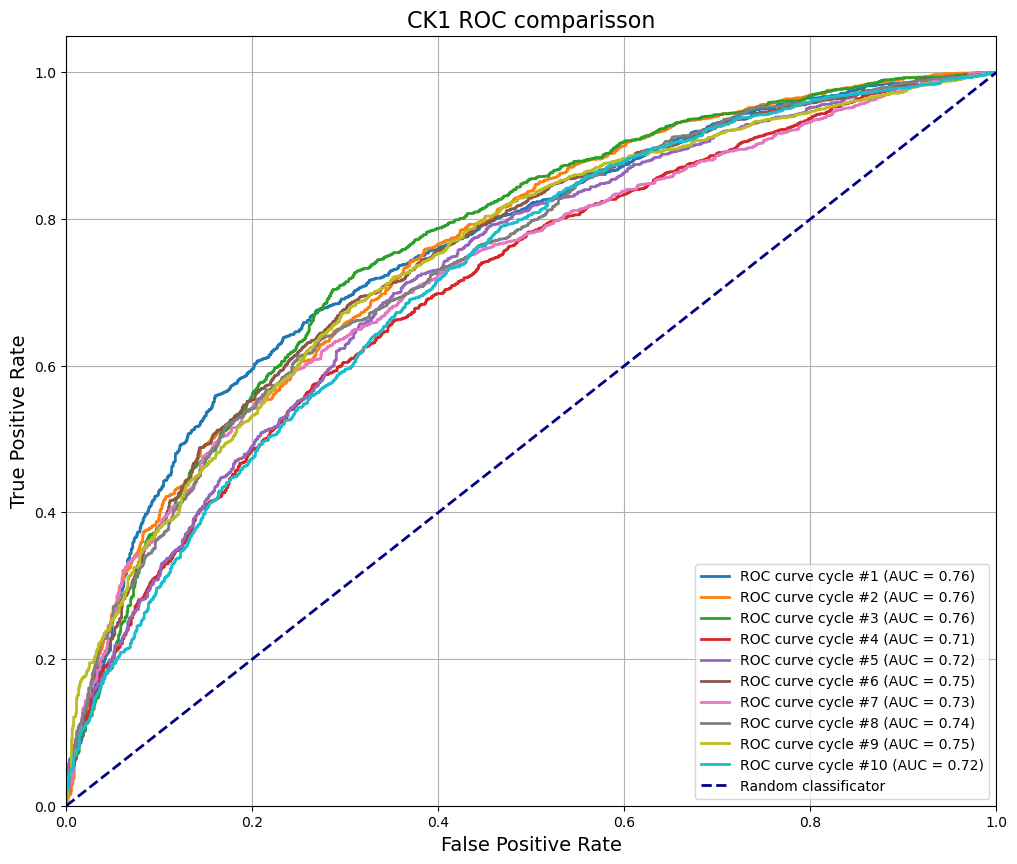

In [22]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"



plt.figure(figsize=(12, 10))

# Projdeme všechny uložené predikce a skutečné hodnoty
for i in range(len(pred_test_mlp)):
    
    # Získáme data pro i-tý cyklus
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    # Vypočítáme ROC křivku a AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Vykreslíme křivku pro tento cyklus do společného grafu
    # (i + 2) použijeme pro správné číslování cyklů, protože váš cyklus začínal od 2
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

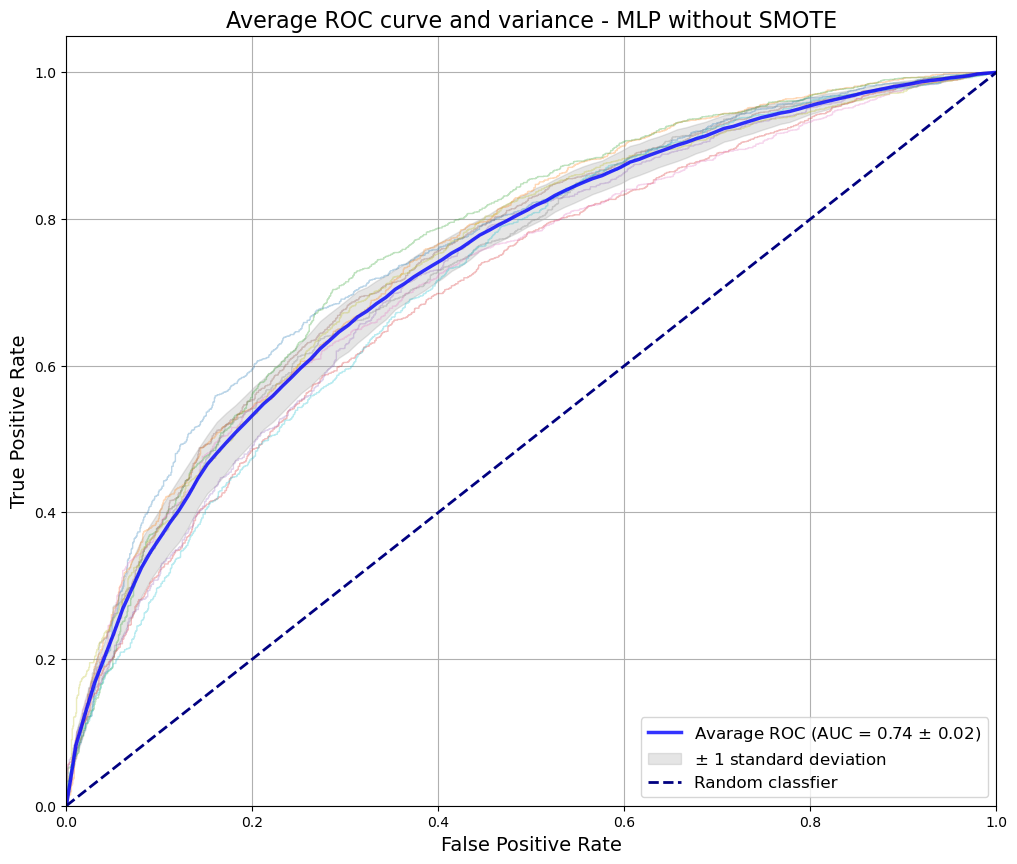

In [38]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('mcc_roc_herg_ws.png', dpi=300, bbox_inches='tight')
plt.show()


In [29]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(f1_score(y_test, (pred_test_knn[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [30]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


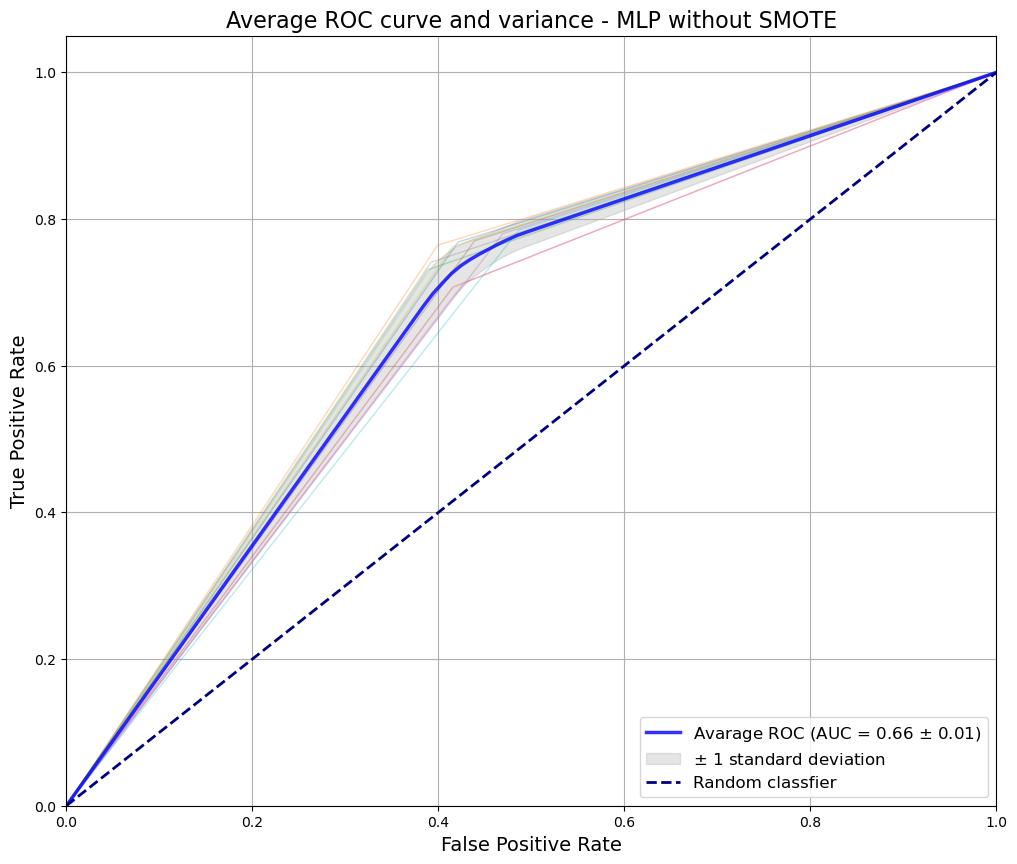

In [26]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3_svc[i]
    y_pred_proba = pred_test_svc[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

/tmp/ipykernel_28807/1026737167.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot([mcc_list, mcc_list_knn, mcc_list_svc], patch_artist=True, labels=['MLP', "KNN", "SVM"])


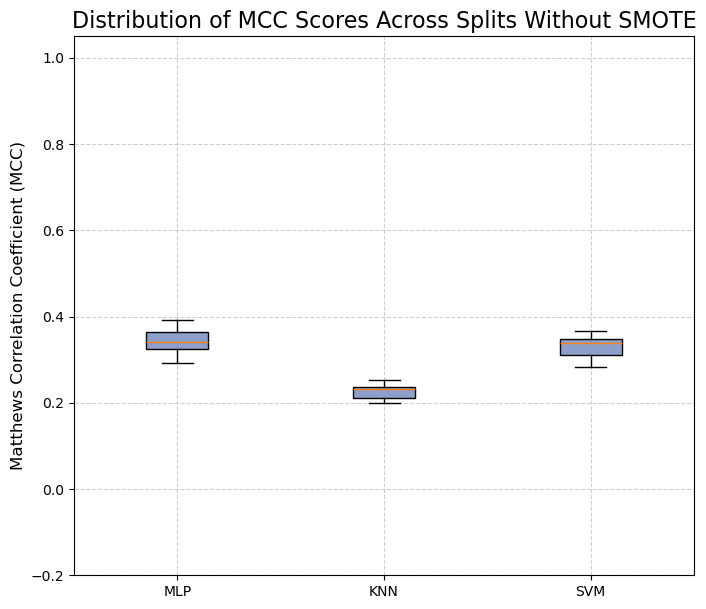

In [27]:
import matplotlib.pyplot as plt

# --- Code to generate a boxplot specifically for MCC scores ---

plt.figure(figsize=(8, 7))

# Create a boxplot for the collected MCC values
# patch_artist=True allows us to color the box
bplot = plt.boxplot([mcc_list, mcc_list_knn, mcc_list_svc], patch_artist=True, labels=['MLP', "KNN", "SVM"])
# Add titles and labels in English
plt.title('Distribution of MCC Scores Across Splits Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)

# MCC scores range from -1 to 1.
# Set the y-axis limits to represent this full range.
plt.ylim([-0.2, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Set a single color for all boxes
box_color = '#8da0cb'  # You can choose any color you like

for box in bplot['boxes']:
    box.set_facecolor(box_color)

plt.show()

In [28]:
[mcc_list, mcc_list_knn, mcc_list_svc]

[[0.36516866666325953,
  0.3474510270905953,
  0.3920867801735328,
  0.29278802036895185,
  0.3323989051785469,
  0.3707082392468813,
  0.322100597087428,
  0.33059045051042923,
  0.360631759127952,
  0.3153596025434111],
 [0.24586271439239007,
  0.253875502629269,
  0.2324225313895414,
  0.20061156925086157,
  0.23027099866086143,
  0.2102578699775346,
  0.21023667371093624,
  0.23238639087490695,
  0.23662813675806665,
  0.19957416446935453],
 [0.3504480275491407,
  0.36742629281305156,
  0.3396796127161722,
  0.28788908172676325,
  0.3191992185556172,
  0.33751067919095,
  0.28286276450936115,
  0.3461039081391339,
  0.34917866657722385,
  0.3085197862909876]]

In [33]:
[f1_list_mlp, f1_list_knn, f1_list_svc]

[[0.7569275644141954,
  0.7179621848739496,
  0.7298355520751761,
  0.6901408450704225,
  0.7386419149975574,
  0.7222651222651223,
  0.7229813664596273,
  0.7258185453636591,
  0.7300127713920818,
  0.7371221281741234],
 [0.7149059334298119,
  0.7158456685270566,
  0.7145877378435518,
  0.6953801732435033,
  0.7170697346795022,
  0.6914639961850262,
  0.6964028776978417,
  0.7177078440582433,
  0.7130600571973308,
  0.7100536505714952],
 [0.7588838540424517,
  0.756175103937393,
  0.7405786530513008,
  0.7225743539736714,
  0.7525629077353215,
  0.7482452035563875,
  0.7235166946913284,
  0.750779563444471,
  0.755067970426902,
  0.753060753060753]]